In [1]:
import json

import gc_utils
import gizmo_analysis as gizmo
import halo_analysis as halo
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utilities as ut
from astropy.io import ascii
from scipy.interpolate import make_smoothing_spline
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter

In [2]:
sim = "m12m"

# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"
sim_codes = sim_dir + "simulation_codes.json"
with open(sim_codes) as sim_json:
    sim_data = json.load(sim_json)

In [3]:
data_directory = "/Users/z5114326/Documents/simulations/m12i/m12i_res7100/"
data_directory = sim_dir + sim + "/" + sim + "_res7100/"

In [4]:
all_data_fil = sim_dir + "/" + "m12i" + "/" + "m12i" + "_res7100/" + "snapshot_times.txt"
all_data = pd.read_table(all_data_fil, comment="#", header=None, sep=r"\s+")
all_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
all_times = np.array(all_data["time_Gyr"])
all_snaps = np.array(all_data["index"])

In [5]:
halt = halo.io.IO.read_tree(simulation_directory=data_directory, species=["star"])


# in utilities.simulation.Snapshot():
* reading:  Volumes/Expansion/simulations/m12m/m12m_res7100/snapshot_times.txt


# in halo_analysis.halo_io.IO():
* read 55240819 halos from:  Volumes/Expansion/simulations/m12m/m12m_res7100/halo/rockstar_dm/catalog_hdf5/tree.hdf5
  
* assigning ['star'] properties to halo merger trees

# in halo_analysis.halo_io.Particle():
* read 22004 halos, 4 have star particles, from:  Volumes/Expansion/simulations/m12m/m12m_res7100/halo/rockstar_dm/catalog_hdf5/star_002.hdf5

# in utilities.simulation.Snapshot():
* reading:  Volumes/Expansion/simulations/m12m/m12m_res7100/snapshot_times.txt

  dark2.mass
  star.form.time.100
  star.form.time.50
  star.form.time.90
  star.form.time.95
  star.form.time.dif.68
  star.indices
  star.mass
  star.massfraction
  star.number
  star.position
  star.radius.50
  star.radius.90
  star.vel.std
  star.vel.std.50
  star.velocity
  
! snapshot 2: 4 halos have star particles but are not in tree
  max M_star = 5.8e+04
* read 

In [6]:
halt.keys()

dict_keys(['am.phantom', 'am.progenitor.main', 'axis.b/a', 'axis.c/a', 'catalog.index', 'central.index', 'central.local.index', 'descendant.index', 'descendant.snapshot', 'dindex', 'final.index', 'host.distance', 'host.index', 'host.velocity', 'host.velocity.rad', 'host.velocity.tan', 'major.merger.snapshot', 'mass', 'mass.180m', 'mass.200c', 'mass.200m', 'mass.500c', 'mass.bound', 'mass.lowres', 'mass.vir', 'position', 'position.offset', 'progenitor.co.dindex', 'progenitor.co.index', 'progenitor.last.dindex', 'progenitor.main.index', 'progenitor.main.last.dindex', 'progenitor.number', 'radius', 'scale.radius', 'scale.radius.klypin', 'snapshot', 'spin.bullock', 'spin.peebles', 'tid', 'vel.circ.max', 'vel.std', 'velocity', 'velocity.offset', 'dark2.mass', 'star.form.time.100', 'star.form.time.50', 'star.form.time.90', 'star.form.time.95', 'star.form.time.dif.68', 'star.indices', 'star.mass', 'star.massfraction', 'star.number', 'star.position', 'star.radius.50', 'star.radius.90', 'star.v

In [7]:
halo_tid = sim_data[sim]["halo"]
halo_tidx = np.where(halt["tid"] == halo_tid)[0][0]

# nprog = halt["progenitor.number"][0]
prog0 = halt["progenitor.main.index"][halo_tidx]
all_progs = []
snap_lst = []

while prog0 > 0:
    snap_lst.append(halt["snapshot"][prog0] + 1)
    progs = [prog0]
    for prog in progs:
        prog_i = halt["progenitor.co.index"][prog]
        if prog_i > 0:
            progs.append(prog_i)
    all_progs.append(progs)
    prog0 = halt["progenitor.main.index"][progs[0]]


# am phantom, seperate out dm only, and those with stars ignore am phantom, # masses?
tim_lst = all_times[snap_lst]

st_lst = []
dm_lst = []
for progs in all_progs:
    pmsk = halt["am.phantom"][progs] == 0
    num_st = np.sum((halt["star.mass"][progs] > 0)[pmsk])
    num_dm = np.sum(pmsk) - num_st

    st_lst.append(num_st)
    dm_lst.append(num_dm)

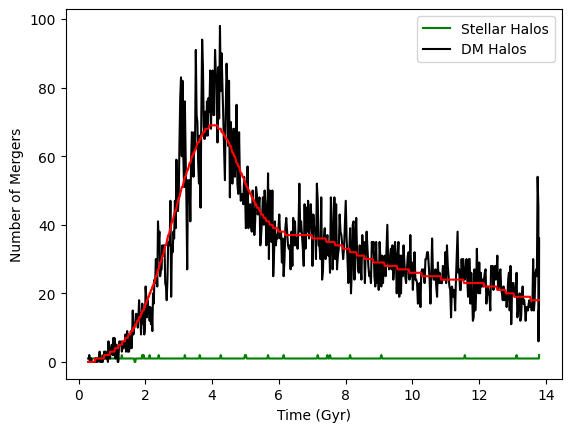

In [8]:
plt.plot(tim_lst, st_lst, c="g", label="Stellar Halos")
plt.plot(tim_lst, dm_lst, c="k", label="DM Halos")

dm_lst_s = gaussian_filter1d(dm_lst, sigma=20)
plt.plot(tim_lst, dm_lst_s, c="r")

plt.xlabel("Time (Gyr)")
plt.ylabel("Number of Mergers")

plt.legend()

In [9]:
all_times[halt["major.merger.snapshot"][halo_tidx]]

np.float64(3.069489337)

In [10]:
st_mass = []
dm_mass = []

st_mass_host = []
dm_mass_host = []
for progs in all_progs:
    mmsk = halt["am.progenitor.main"][progs] == 0
    pmsk = halt["am.phantom"][progs] == 0
    stmsk = halt["star.mass"][progs] > 0

    st_mass.append(np.sum(halt["star.mass"][progs][mmsk & pmsk & stmsk]))
    dm_mass.append(np.sum(halt["mass"][progs][mmsk & pmsk]))

    st_mass_host.append(np.sum(halt["star.mass"][progs][~mmsk & pmsk & stmsk]))
    dm_mass_host.append(np.sum(halt["mass"][progs][~mmsk & pmsk]))

(0.0, 51264383385.6)

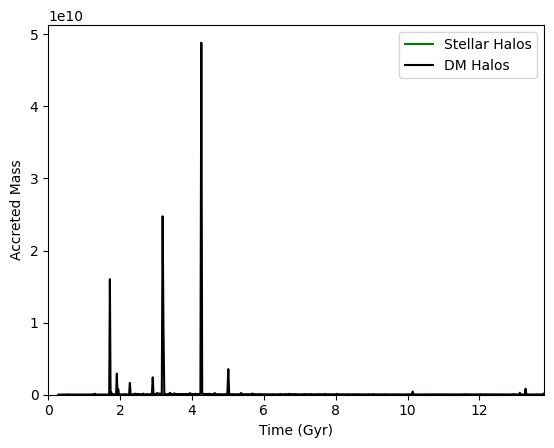

In [11]:
plt.plot(tim_lst, st_mass, c="g", label="Stellar Halos")
plt.plot(tim_lst, dm_mass, c="k", label="DM Halos")

# dm_mass_s = gaussian_filter1d(dm_mass, sigma=5)
# plt.plot(tim_lst, dm_mass_s, c="r")

plt.xlabel("Time (Gyr)")
plt.ylabel("Accreted Mass")

plt.legend()
# plt.yscale("log")

plt.xlim(0, 13.8)
plt.ylim(0)

(0.0, 0.4493726223707199)

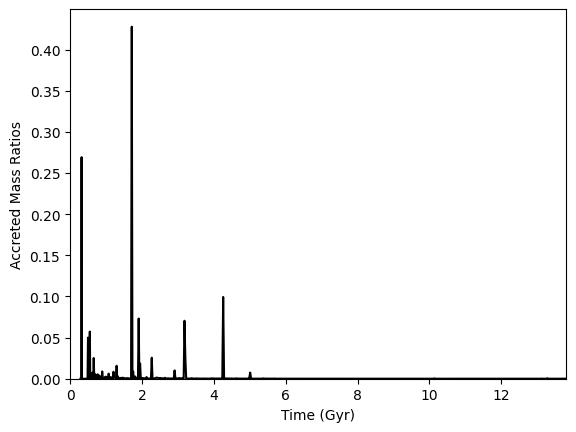

In [12]:
rat = (np.array(st_mass) + np.array(dm_mass)) / (np.array(st_mass_host) + np.array(dm_mass_host))

plt.plot(tim_lst, rat, c="k")

# dm_mass_s = gaussian_filter1d(dm_mass, sigma=5)
# plt.plot(tim_lst, dm_mass_s, c="r")

plt.xlabel("Time (Gyr)")
plt.ylabel("Accreted Mass Ratios")

# plt.yscale("log")

plt.xlim(0, 13.8)
plt.ylim(0)